In [1]:
import pandas as pd
import polars as pl
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import npc_lims
# from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils
import lazynwb

import os
import pickle
import upath

%load_ext autoreload
%autoreload 2
# %matplotlib widget

In [2]:
session_id='742903_2024-10-22' #good DR
# session_id="664851_2023-11-13" #mediocre DR
# session_id="670180_2023-07-27" #templeton

session_info=npc_lims.get_session_info(session_id)
trials=data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
units=data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

742903_2024-10-22 cached trials loaded
742903_2024-10-22 cached units loaded


In [13]:
#filter units

units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.1 and \
    firing_rate>=0.5 and \
    ~structure.isna() and ~location.isna()'
    ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])


In [4]:
#make data arrays

time_before = 0.1
time_after = 0.01
binsize = 0.1
baseline_trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize)

time_before = 0.0
time_after = 0.11
binsize = 0.1
stim_trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize)

# Matched-bin baseline for evoked subtraction (same 0.1s bin as stimulus)
baseline_matched_trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, 0.1, 0.01, 0.1)

In [59]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_train_baseline = baseline_trial_da.data.reshape(baseline_trial_da.data.shape[0], -1).T
y_train_baseline = trials['is_vis_rewarded']
baseline_lda = LinearDiscriminantAnalysis(n_components=1) # Project to 1 dimension
baseline_lda.fit(X_train_baseline, y_train_baseline)

X_train_vis_stim = stim_trial_da.sel(trials=trials.query('is_vis_target')['trial_index'].values).data.reshape(stim_trial_da.data.shape[0], -1).T
y_train_vis_stim = trials.query('is_vis_target')['is_vis_rewarded']
vis_stim_lda = LinearDiscriminantAnalysis(n_components=1) # Project to 1 dimension
vis_stim_lda.fit(X_train_vis_stim, y_train_vis_stim)

X_train_aud_stim = stim_trial_da.sel(trials=trials.query('is_aud_target')['trial_index'].values).data.reshape(stim_trial_da.data.shape[0], -1).T
y_train_aud_stim = trials.query('is_aud_target')['is_vis_rewarded']
aud_stim_lda = LinearDiscriminantAnalysis(n_components=1) # Project to 1 dimension
aud_stim_lda.fit(X_train_aud_stim, y_train_aud_stim)

X_train_vis_id = stim_trial_da.sel(trials=trials.query('is_vis_stim')['trial_index'].values).data.reshape(stim_trial_da.data.shape[0], -1).T
y_train_vis_id = trials.query('is_vis_stim')['is_vis_target']
vis_id_lda = LinearDiscriminantAnalysis(n_components=1) # Project to 1 dimension
vis_id_lda.fit(X_train_vis_id, y_train_vis_id)

X_train_aud_id = stim_trial_da.sel(trials=trials.query('is_aud_stim')['trial_index'].values).data.reshape(stim_trial_da.data.shape[0], -1).T
y_train_aud_id = trials.query('is_aud_stim')['is_aud_target']
aud_id_lda = LinearDiscriminantAnalysis(n_components=1) # Project to 1 dimension
aud_id_lda.fit(X_train_aud_id, y_train_aud_id)

# Evoked activity (stimulus - matched baseline, per neuron per trial)
n_neurons = baseline_matched_trial_da.data.shape[0]
X_matched_baseline_vis = baseline_matched_trial_da.sel(trials=trials.query('is_vis_target')['trial_index'].values).data.reshape(n_neurons, -1).T
X_matched_baseline_aud = baseline_matched_trial_da.sel(trials=trials.query('is_aud_target')['trial_index'].values).data.reshape(n_neurons, -1).T

X_train_evoked_vis = X_train_vis_stim - X_matched_baseline_vis
X_train_evoked_aud = X_train_aud_stim - X_matched_baseline_aud

evoked_vis_lda = LinearDiscriminantAnalysis(n_components=1)
evoked_vis_lda.fit(X_train_evoked_vis, y_train_vis_stim)

evoked_aud_lda = LinearDiscriminantAnalysis(n_components=1)
evoked_aud_lda.fit(X_train_evoked_aud, y_train_aud_stim)

# evoked activity for stim id 
X_matched_baseline_vis_id = baseline_matched_trial_da.sel(trials=trials.query('is_vis_stim')['trial_index'].values).data.reshape(n_neurons, -1).T
X_matched_baseline_aud_id = baseline_matched_trial_da.sel(trials=trials.query('is_aud_stim')['trial_index'].values).data.reshape(n_neurons, -1).T

X_train_evoked_vis_id = X_train_vis_id - X_matched_baseline_vis_id
X_train_evoked_aud_id = X_train_aud_id - X_matched_baseline_aud_id

evoked_vis_id_lda = LinearDiscriminantAnalysis(n_components=1)
evoked_vis_id_lda.fit(X_train_evoked_vis_id, y_train_vis_id)

evoked_aud_id_lda = LinearDiscriminantAnalysis(n_components=1)
evoked_aud_id_lda.fit(X_train_evoked_aud_id, y_train_aud_id)


LinearDiscriminantAnalysis(n_components=1)

In [ ]:
# get angles between the LDA projection vectors
baseline_vector = baseline_lda.coef_.flatten()
vis_stim_vector = vis_stim_lda.coef_.flatten()
aud_stim_vector = aud_stim_lda.coef_.flatten()
evoked_vis_vector = evoked_vis_lda.coef_.flatten()
evoked_aud_vector = evoked_aud_lda.coef_.flatten()


def angle_between_vectors(v1, v2):
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle_rad = np.arccos(np.clip(cos_angle, -1.0, 1.0))  # Clip for numerical stability
    angle_deg = np.degrees(angle_rad)
    return angle_deg

angle_baseline_vis = angle_between_vectors(baseline_vector, vis_stim_vector)
angle_baseline_aud = angle_between_vectors(baseline_vector, aud_stim_vector)
angle_vis_aud = angle_between_vectors(vis_stim_vector, aud_stim_vector)
print(f"--- Raw stimulus ---")
print(f"Angle between baseline and visual stim LDA vectors: {angle_baseline_vis:.2f} degrees")
print(f"Angle between baseline and auditory stim LDA vectors: {angle_baseline_aud:.2f} degrees")
print(f"Angle between visual and auditory stim LDA vectors: {angle_vis_aud:.2f} degrees")

print(f"\n--- Evoked (stimulus - baseline) ---")
angle_baseline_evoked_vis = angle_between_vectors(baseline_vector, evoked_vis_vector)
angle_baseline_evoked_aud = angle_between_vectors(baseline_vector, evoked_aud_vector)
angle_evoked_vis_aud = angle_between_vectors(evoked_vis_vector, evoked_aud_vector)
angle_vis_evoked_vis = angle_between_vectors(vis_stim_vector, evoked_vis_vector)
angle_aud_evoked_aud = angle_between_vectors(aud_stim_vector, evoked_aud_vector)
print(f"Angle between baseline and evoked visual LDA vectors: {angle_baseline_evoked_vis:.2f} degrees")
print(f"Angle between baseline and evoked auditory LDA vectors: {angle_baseline_evoked_aud:.2f} degrees")
print(f"Angle between evoked visual and evoked auditory LDA vectors: {angle_evoked_vis_aud:.2f} degrees")
print(f"Angle between raw visual stim and evoked visual LDA vectors: {angle_vis_evoked_vis:.2f} degrees")
print(f"Angle between raw auditory stim and evoked auditory LDA vectors: {angle_aud_evoked_aud:.2f} degrees")

--- Raw stimulus ---
Angle between baseline and visual stim LDA vectors: 83.12 degrees
Angle between baseline and auditory stim LDA vectors: 91.73 degrees
Angle between visual and auditory stim LDA vectors: 92.31 degrees

--- Evoked (stimulus - baseline) ---
Angle between baseline and evoked visual LDA vectors: 96.68 degrees
Angle between baseline and evoked auditory LDA vectors: 83.04 degrees
Angle between evoked visual and evoked auditory LDA vectors: 94.58 degrees
Angle between raw visual stim and evoked visual LDA vectors: 80.84 degrees
Angle between raw auditory stim and evoked auditory LDA vectors: 74.02 degrees


Correlation between baseline and visual stim projections: r=0.61, p=0.000
Correlation between baseline and auditory stim projections: r=0.67, p=0.000
Correlation between baseline and evoked visual projections: r=0.46, p=0.000
Correlation between baseline and evoked auditory projections: r=0.51, p=0.000


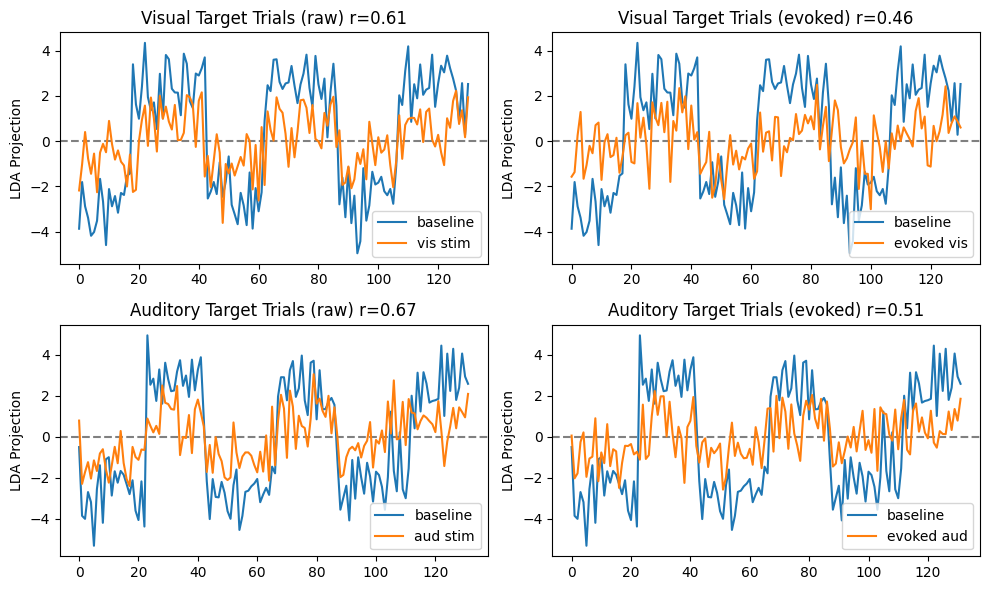

In [7]:
X_baseline = baseline_lda.transform(X_train_baseline)
X_vis_stim = vis_stim_lda.transform(X_train_vis_stim)
X_aud_stim = aud_stim_lda.transform(X_train_aud_stim)
X_evoked_vis = evoked_vis_lda.transform(X_train_evoked_vis)
X_evoked_aud = evoked_aud_lda.transform(X_train_evoked_aud)

vis_stim_trial_index = trials.query('is_vis_target').index.values
aud_stim_trial_index = trials.query('is_aud_target').index.values

rvis,pvis=stats.pearsonr(X_baseline[vis_stim_trial_index].flatten(), X_vis_stim.flatten())
raud,paud=stats.pearsonr(X_baseline[aud_stim_trial_index].flatten(), X_aud_stim.flatten())
print(f"Correlation between baseline and visual stim projections: r={rvis:.2f}, p={pvis:.3f}")
print(f"Correlation between baseline and auditory stim projections: r={raud:.2f}, p={paud:.3f}")

r_evoked_vis, p_evoked_vis = stats.pearsonr(X_baseline[vis_stim_trial_index].flatten(), X_evoked_vis.flatten())
r_evoked_aud, p_evoked_aud = stats.pearsonr(X_baseline[aud_stim_trial_index].flatten(), X_evoked_aud.flatten())
print(f"Correlation between baseline and evoked visual projections: r={r_evoked_vis:.2f}, p={p_evoked_vis:.3f}")
print(f"Correlation between baseline and evoked auditory projections: r={r_evoked_aud:.2f}, p={p_evoked_aud:.3f}")

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax[0, 0].axhline(0, color='gray', linestyle='--')
ax[0, 0].plot(X_baseline[vis_stim_trial_index], '-', label='baseline')
ax[0, 0].plot(X_vis_stim, '-', label='vis stim')
ax[0, 0].set_title(f'Visual Target Trials (raw) r={rvis:.2f}')
ax[0, 0].set_ylabel('LDA Projection')
ax[0, 0].legend()

ax[1, 0].axhline(0, color='gray', linestyle='--')
ax[1, 0].plot(X_baseline[aud_stim_trial_index], '-', label='baseline')
ax[1, 0].plot(X_aud_stim, '-', label='aud stim')
ax[1, 0].set_title(f'Auditory Target Trials (raw) r={raud:.2f}')
ax[1, 0].set_ylabel('LDA Projection')
ax[1, 0].legend()

ax[0, 1].axhline(0, color='gray', linestyle='--')
ax[0, 1].plot(X_baseline[vis_stim_trial_index], '-', label='baseline')
ax[0, 1].plot(X_evoked_vis, '-', label='evoked vis')
ax[0, 1].set_title(f'Visual Target Trials (evoked) r={r_evoked_vis:.2f}')
ax[0, 1].set_ylabel('LDA Projection')
ax[0, 1].legend()

ax[1, 1].axhline(0, color='gray', linestyle='--')
ax[1, 1].plot(X_baseline[aud_stim_trial_index], '-', label='baseline')
ax[1, 1].plot(X_evoked_aud, '-', label='evoked aud')
ax[1, 1].set_title(f'Auditory Target Trials (evoked) r={r_evoked_aud:.2f}')
ax[1, 1].set_ylabel('LDA Projection')
ax[1, 1].legend()

fig.tight_layout()

Correlation between baseline and visual stim projections: r=0.51, p=0.000
Correlation between baseline and auditory stim projections: r=0.63, p=0.000
Correlation between baseline and evoked visual projections: r=-0.04, p=0.487
Correlation between baseline and evoked auditory projections: r=-0.09, p=0.144


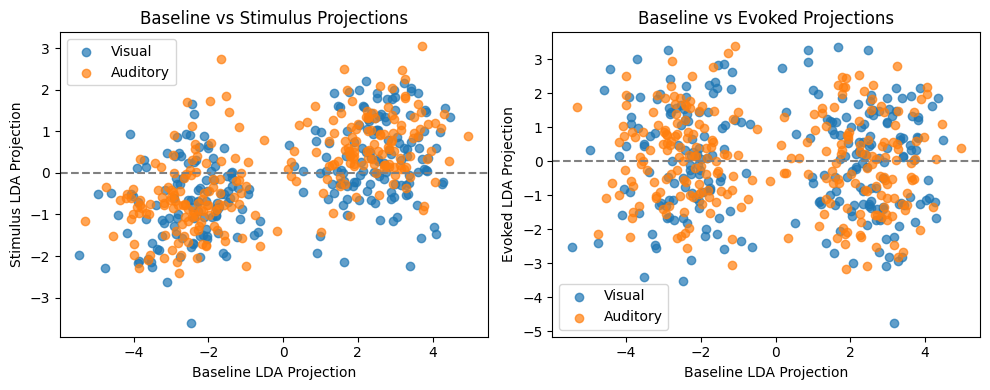

In [62]:
X_baseline = baseline_lda.transform(X_train_baseline)
X_vis_id = vis_stim_lda.transform(X_train_vis_id)
X_aud_id = aud_stim_lda.transform(X_train_aud_id)
X_evoked_vis_id = evoked_vis_id_lda.transform(X_train_evoked_vis_id)
X_evoked_aud_id = evoked_aud_id_lda.transform(X_train_evoked_aud_id)

vis_id_trial_index = trials.query('is_vis_stim').index.values
aud_id_trial_index = trials.query('is_aud_stim').index.values

rvis,pvis=stats.pearsonr(X_baseline[vis_id_trial_index].flatten(), X_vis_id.flatten())
raud,paud=stats.pearsonr(X_baseline[aud_id_trial_index].flatten(), X_aud_id.flatten())
print(f"Correlation between baseline and visual stim projections: r={rvis:.2f}, p={pvis:.3f}")
print(f"Correlation between baseline and auditory stim projections: r={raud:.2f}, p={paud:.3f}")

r_evoked_vis, p_evoked_vis = stats.pearsonr(X_baseline[vis_id_trial_index].flatten(), X_evoked_vis_id.flatten())
r_evoked_aud, p_evoked_aud = stats.pearsonr(X_baseline[aud_id_trial_index].flatten(), X_evoked_aud_id.flatten())
print(f"Correlation between baseline and evoked visual projections: r={r_evoked_vis:.2f}, p={p_evoked_vis:.3f}")
print(f"Correlation between baseline and evoked auditory projections: r={r_evoked_aud:.2f}, p={p_evoked_aud:.3f}")

fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].axhline(0, color='gray', linestyle='--')
ax[0].scatter(X_baseline[vis_id_trial_index], X_vis_id, label='Visual', alpha=0.7)
ax[0].scatter(X_baseline[aud_id_trial_index], X_aud_id, label='Auditory', alpha=0.7)
ax[0].set_title('Baseline vs Stimulus Projections')
ax[0].set_xlabel('Baseline LDA Projection')
ax[0].set_ylabel('Stimulus LDA Projection')
ax[0].legend()
ax[1].axhline(0, color='gray', linestyle='--')
ax[1].scatter(X_baseline[vis_id_trial_index], X_evoked_vis_id, label='Visual', alpha=0.7)
ax[1].scatter(X_baseline[aud_id_trial_index], X_evoked_aud_id, label='Auditory', alpha=0.7)
ax[1].set_title('Baseline vs Evoked Projections')
ax[1].set_xlabel('Baseline LDA Projection')
ax[1].set_ylabel('Evoked LDA Projection')
ax[1].legend()
fig.tight_layout()

In [29]:
rs=[]
ps=[]
for uu in range(X_train_evoked_vis.shape[1]):
    sel_unit=uu
    r,p=stats.pearsonr(X_baseline[vis_stim_trial_index].flatten(),X_train_evoked_vis[:,sel_unit])
    rs.append(r)
    ps.append(p)

C:\Users\ethan.mcbride\AppData\Local\Temp\ipykernel_28952\3403269018.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p=stats.pearsonr(X_baseline[vis_stim_trial_index].flatten(),X_train_evoked_vis[:,sel_unit])


In [50]:
np.where(np.array(ps)<0.01)

(array([ 56, 123, 166, 260, 299, 363, 530, 555, 563, 613, 642], dtype=int64),)

Text(0.5, 1.0, 'Unit 642 (MOs), r=0.23, p=0.009')

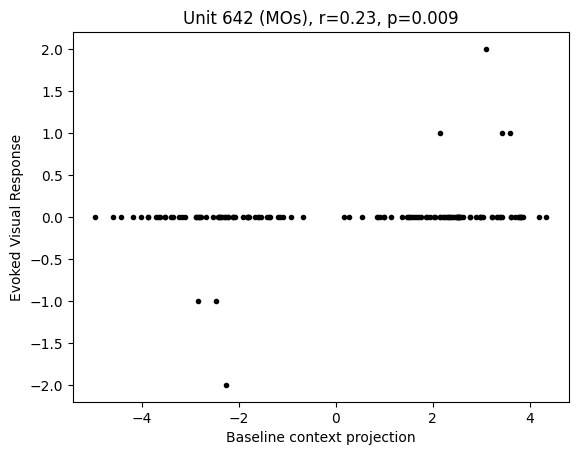

In [58]:
sel_unit=642
unit_info=units_filtered.iloc[sel_unit]

fig,ax=plt.subplots(1,1)
ax.plot(X_baseline[vis_stim_trial_index].flatten(),X_train_evoked_vis[:,sel_unit]*0.1,'k.')
ax.set_xlabel('Baseline context projection')
ax.set_ylabel('Evoked Visual Response')
ax.set_title(f'Unit {sel_unit} ({unit_info["structure"]}), r={rs[sel_unit]:.2f}, p={ps[sel_unit]:.3f}')

In [62]:
vis_target_vis_block_index = trials.query('is_vis_target and is_vis_rewarded').index.values
vis_target_aud_block_index = trials.query('is_vis_target and is_aud_rewarded').index.values

aud_target_vis_block_index = trials.query('is_aud_target and is_vis_rewarded').index.values
aud_target_aud_block_index = trials.query('is_aud_target and is_aud_rewarded').index.values

r_vis_in_vis,p_vis_in_vis=stats.pearsonr(X_baseline[vis_target_vis_block_index].flatten(), X_vis_stim[trials.query('is_vis_target')['is_vis_rewarded']].flatten())
r_vis_in_aud,p_vis_in_aud=stats.pearsonr(X_baseline[vis_target_aud_block_index].flatten(), X_vis_stim[trials.query('is_vis_target')['is_aud_rewarded']].flatten())

r_aud_in_vis,p_aud_in_vis=stats.pearsonr(X_baseline[aud_target_vis_block_index].flatten(), X_aud_stim[trials.query('is_aud_target')['is_vis_rewarded']].flatten())
r_aud_in_aud,p_aud_in_aud=stats.pearsonr(X_baseline[aud_target_aud_block_index].flatten(), X_aud_stim[trials.query('is_aud_target')['is_aud_rewarded']].flatten())

print(f"--- Raw stimulus ---")
print(f"Baseline vs visual stim in visual blocks: r={r_vis_in_vis:.2f}, p={p_vis_in_vis:.3f}")
print(f"Baseline vs visual stim in auditory blocks: r={r_vis_in_aud:.2f}, p={p_vis_in_aud:.3f}")
print(f"Baseline vs auditory stim in visual blocks: r={r_aud_in_vis:.2f}, p={p_aud_in_vis:.3f}")
print(f"Baseline vs auditory stim in auditory blocks: r={r_aud_in_aud:.2f}, p={p_aud_in_aud:.3f}")

# Evoked context-separated correlations
r_evoked_vis_in_vis, p_evoked_vis_in_vis = stats.pearsonr(X_baseline[vis_target_vis_block_index].flatten(), X_evoked_vis[trials.query('is_vis_target')['is_vis_rewarded']].flatten())
r_evoked_vis_in_aud, p_evoked_vis_in_aud = stats.pearsonr(X_baseline[vis_target_aud_block_index].flatten(), X_evoked_vis[trials.query('is_vis_target')['is_aud_rewarded']].flatten())

r_evoked_aud_in_vis, p_evoked_aud_in_vis = stats.pearsonr(X_baseline[aud_target_vis_block_index].flatten(), X_evoked_aud[trials.query('is_aud_target')['is_vis_rewarded']].flatten())
r_evoked_aud_in_aud, p_evoked_aud_in_aud = stats.pearsonr(X_baseline[aud_target_aud_block_index].flatten(), X_evoked_aud[trials.query('is_aud_target')['is_aud_rewarded']].flatten())

print(f"\n--- Evoked (stimulus - baseline) ---")
print(f"Baseline vs evoked visual in visual blocks: r={r_evoked_vis_in_vis:.2f}, p={p_evoked_vis_in_vis:.3f}")
print(f"Baseline vs evoked visual in auditory blocks: r={r_evoked_vis_in_aud:.2f}, p={p_evoked_vis_in_aud:.3f}")
print(f"Baseline vs evoked auditory in visual blocks: r={r_evoked_aud_in_vis:.2f}, p={p_evoked_aud_in_vis:.3f}")
print(f"Baseline vs evoked auditory in auditory blocks: r={r_evoked_aud_in_aud:.2f}, p={p_evoked_aud_in_aud:.3f}")

--- Raw stimulus ---
Baseline vs visual stim in visual blocks: r=0.28, p=0.014
Baseline vs visual stim in auditory blocks: r=0.26, p=0.053
Baseline vs auditory stim in visual blocks: r=0.31, p=0.018
Baseline vs auditory stim in auditory blocks: r=0.35, p=0.002

--- Evoked (stimulus - baseline) ---
Baseline vs evoked visual in visual blocks: r=0.07, p=0.555
Baseline vs evoked visual in auditory blocks: r=0.13, p=0.327
Baseline vs evoked auditory in visual blocks: r=0.29, p=0.026
Baseline vs evoked auditory in auditory blocks: r=0.23, p=0.049


In [63]:
# select structure, exclude instruction trials, flip aud block trials


In [64]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

In [65]:
import traceback

results = {}
save_dir = upath.UPath(r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\LDA baseline vs stimulus context modulation")
save_dir.mkdir(parents=True, exist_ok=True)

for session_id in dr_session_list:
    print(f"Processing session: {session_id}")
    try:
        session_info = npc_lims.get_session_info(session_id)
        trials_s = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
        units_s = data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

        units_filtered_s = units_s.query(
            'presence_ratio>=0.7 and \
            isi_violations_ratio<=0.5 and \
            amplitude_cutoff<=0.1 and \
            activity_drift<=0.1 and \
            firing_rate>=0.5 and \
            ~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

        if len(units_filtered_s) == 0:
            print(f"  No units after filtering, skipping.")
            continue

        structures = units_filtered_s['structure'].unique()

        for structure in structures:
            units_structure_s = units_filtered_s.query('structure == @structure')

            if len(units_structure_s) < 10:
                print(f"  {structure}: only {len(units_structure_s)} units, skipping (need >= 10).")
                continue

            # Baseline tensor (0.5s bin)
            baseline_trial_da_s = spike_utils.make_neuron_time_trials_tensor(
                units_structure_s, trials_s, 0.5, 0.01, 0.5
            )
            # Stim tensor (0.1s bin)
            stim_trial_da_s = spike_utils.make_neuron_time_trials_tensor(
                units_structure_s, trials_s, 0.0, 0.11, 0.1
            )
            # Matched-bin baseline for evoked subtraction (same 0.1s bin as stimulus)
            baseline_matched_trial_da_s = spike_utils.make_neuron_time_trials_tensor(
                units_structure_s, trials_s, 0.1, 0.01, 0.1
            )

            n_neurons_s = stim_trial_da_s.data.shape[0]

            X_train_baseline_s = baseline_trial_da_s.data.reshape(baseline_trial_da_s.data.shape[0], -1).T
            y_train_baseline_s = trials_s['is_vis_rewarded']

            X_train_vis_s = stim_trial_da_s.sel(trials=trials_s.query('is_vis_target')['trial_index'].values).data.reshape(n_neurons_s, -1).T
            y_train_vis_s = trials_s.query('is_vis_target')['is_vis_rewarded']

            X_train_aud_s = stim_trial_da_s.sel(trials=trials_s.query('is_aud_target')['trial_index'].values).data.reshape(n_neurons_s, -1).T
            y_train_aud_s = trials_s.query('is_aud_target')['is_vis_rewarded']

            # Evoked activity (stimulus - matched baseline)
            X_matched_baseline_vis_s = baseline_matched_trial_da_s.sel(
                trials=trials_s.query('is_vis_target')['trial_index'].values
            ).data.reshape(n_neurons_s, -1).T
            X_matched_baseline_aud_s = baseline_matched_trial_da_s.sel(
                trials=trials_s.query('is_aud_target')['trial_index'].values
            ).data.reshape(n_neurons_s, -1).T

            X_train_evoked_vis_s = X_train_vis_s - X_matched_baseline_vis_s
            X_train_evoked_aud_s = X_train_aud_s - X_matched_baseline_aud_s

            if y_train_baseline_s.nunique() < 2 or y_train_vis_s.nunique() < 2 or y_train_aud_s.nunique() < 2:
                print(f"  {structure}: Not enough class variety, skipping.")
                continue

            baseline_lda_s = LinearDiscriminantAnalysis(n_components=1)
            baseline_lda_s.fit(X_train_baseline_s, y_train_baseline_s)

            vis_lda_s = LinearDiscriminantAnalysis(n_components=1)
            vis_lda_s.fit(X_train_vis_s, y_train_vis_s)

            aud_lda_s = LinearDiscriminantAnalysis(n_components=1)
            aud_lda_s.fit(X_train_aud_s, y_train_aud_s)

            evoked_vis_lda_s = LinearDiscriminantAnalysis(n_components=1)
            evoked_vis_lda_s.fit(X_train_evoked_vis_s, y_train_vis_s)

            evoked_aud_lda_s = LinearDiscriminantAnalysis(n_components=1)
            evoked_aud_lda_s.fit(X_train_evoked_aud_s, y_train_aud_s)

            X_proj_baseline_s = baseline_lda_s.transform(X_train_baseline_s)
            X_proj_vis_s = vis_lda_s.transform(X_train_vis_s)
            X_proj_aud_s = aud_lda_s.transform(X_train_aud_s)
            X_proj_evoked_vis_s = evoked_vis_lda_s.transform(X_train_evoked_vis_s)
            X_proj_evoked_aud_s = evoked_aud_lda_s.transform(X_train_evoked_aud_s)

            session_structure_results = {
                'models': {
                    'baseline_lda': baseline_lda_s,
                    'vis_stim_lda': vis_lda_s,
                    'aud_stim_lda': aud_lda_s,
                    'evoked_vis_lda': evoked_vis_lda_s,
                    'evoked_aud_lda': evoked_aud_lda_s,
                },
                'projections': {
                    'baseline': X_proj_baseline_s,
                    'vis_stim': X_proj_vis_s,
                    'aud_stim': X_proj_aud_s,
                    'evoked_vis': X_proj_evoked_vis_s,
                    'evoked_aud': X_proj_evoked_aud_s,
                },
                'trial_indices': {
                    'baseline': trials_s.index.values,
                    'vis_stim': trials_s.query('is_vis_target').index.values,
                    'aud_stim': trials_s.query('is_aud_target').index.values,
                    'evoked_vis': trials_s.query('is_vis_target').index.values,
                    'evoked_aud': trials_s.query('is_aud_target').index.values,
                },
                'labels': {
                    'baseline': y_train_baseline_s.values,
                    'vis_stim': y_train_vis_s.values,
                    'aud_stim': y_train_aud_s.values,
                    'evoked_vis': y_train_vis_s.values,
                    'evoked_aud': y_train_aud_s.values,
                },
                'n_units': len(units_structure_s),
            }

            results[(session_id, structure)] = session_structure_results
            print(f"  {structure}: {len(units_structure_s)} units, done.")

        save_path = save_dir / f"{session_id}_lda_results.pkl"
        with open(save_path, 'wb') as f:
            pickle.dump({k: v for k, v in results.items() if k[0] == session_id}, f)

        print(f"  Saved results to {save_path}")

    except Exception as e:
        print(f"  Error processing session {session_id}: {e}")
        traceback.print_exc()

print("Done processing all sessions.")

Processing session: 626791_2022-08-15
626791_2022-08-15 cached trials loaded
626791_2022-08-15 cached units loaded
  VPM: 16 units, done.
  PO: 29 units, done.
  LP: 29 units, done.
  LD: 15 units, done.
  DG: 19 units, done.
  CA3: only 1 units, skipping (need >= 10).
  CA1: 27 units, done.
  RSPd: only 3 units, skipping (need >= 10).
  ZI: only 1 units, skipping (need >= 10).
  LGv: only 1 units, skipping (need >= 10).
  IGL: only 1 units, skipping (need >= 10).
  TH: only 1 units, skipping (need >= 10).
  LGd: 22 units, done.
  VISpm: 22 units, done.
  AUDp: 20 units, done.
  AUDpo: 37 units, done.
  TEa: 25 units, done.
  VISli: only 2 units, skipping (need >= 10).
  out of brain: only 3 units, skipping (need >= 10).
  STR: only 8 units, skipping (need >= 10).
  CP: 60 units, done.
  MOs: 24 units, done.
  Saved results to \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\LDA baseline vs stimulus context modulation\626791_2022-08-15_lda_results.pkl
Processing session: 6267

In [8]:
save_dir = upath.UPath(r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\LDA baseline vs stimulus context modulation")


session_trial_metadata = {}


def get_session_trial_metadata(session_id):
    if session_id not in session_trial_metadata:
        session_info = npc_lims.get_session_info(session_id)
        trials_s = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
        session_trial_metadata[session_id] = (
            trials_s[['trial_index', 'is_instruction', 'is_vis_rewarded']]
            .drop_duplicates('trial_index')
            .set_index('trial_index')
            .sort_index()
        )

    return session_trial_metadata[session_id]


def make_projection_df(values, trial_indices, trial_metadata, labels=None, flip_auditory_blocks=True, exclude_instruction_trials=True):
    projection_df = pd.DataFrame({
        'trial_index': np.asarray(trial_indices),
        'value': np.asarray(values).reshape(-1),
    })

    if labels is not None:
        projection_df['label'] = np.asarray(labels).astype(bool)

    projection_df = projection_df.merge(
        trial_metadata[['is_instruction', 'is_vis_rewarded']],
        left_on='trial_index',
        right_index=True,
        how='left',
    )

    if labels is None:
        projection_df['label'] = projection_df['is_vis_rewarded'].astype(bool)

    if exclude_instruction_trials:
        projection_df = projection_df.loc[~projection_df['is_instruction'].fillna(False)]

    if flip_auditory_blocks:
        projection_df.loc[~projection_df['label'], 'value'] *= -1

    return projection_df.drop_duplicates('trial_index').set_index('trial_index').sort_index()


def compute_aligned_pearson(values_a, trial_indices_a, values_b, trial_indices_b, trial_metadata, labels_a=None, label_a=None, labels_b=None, label_b=None):
    projection_a = make_projection_df(values_a, trial_indices_a, trial_metadata, labels=labels_a)
    projection_b = make_projection_df(values_b, trial_indices_b, trial_metadata, labels=labels_b)

    if label_a is not None:
        projection_a = projection_a.loc[projection_a['label'] == label_a]
    if label_b is not None:
        projection_b = projection_b.loc[projection_b['label'] == label_b]

    common_trial_indices = projection_a.index.intersection(projection_b.index)
    aligned_a = projection_a.loc[common_trial_indices, 'value'].to_numpy()
    aligned_b = projection_b.loc[common_trial_indices, 'value'].to_numpy()

    if len(common_trial_indices) < 2:
        return np.nan, np.nan, len(common_trial_indices)

    if np.unique(aligned_a).size < 2 or np.unique(aligned_b).size < 2:
        return np.nan, np.nan, len(common_trial_indices)

    r_value, p_value = stats.pearsonr(aligned_a, aligned_b)
    return r_value, p_value, len(common_trial_indices)


records = []
for result_path in sorted(save_dir.glob("*_lda_results.pkl")):
    with open(result_path, 'rb') as f:
        session_results = pickle.load(f)

    for key, result in session_results.items():
        if isinstance(key, tuple) and len(key) == 2:
            session_id, structure = key
        else:
            session_id = result_path.stem.replace('_lda_results', '')
            structure = key

        trial_metadata = get_session_trial_metadata(session_id)

        baseline_projection = np.asarray(result['projections']['baseline']).reshape(-1)
        vis_stim_projection = np.asarray(result['projections']['vis_stim']).reshape(-1)
        aud_stim_projection = np.asarray(result['projections']['aud_stim']).reshape(-1)

        baseline_trial_indices = np.asarray(result['trial_indices']['baseline'])
        vis_stim_trial_indices = np.asarray(result['trial_indices']['vis_stim'])
        aud_stim_trial_indices = np.asarray(result['trial_indices']['aud_stim'])

        baseline_labels = np.asarray(result['labels']['baseline']).astype(bool)
        vis_stim_labels = np.asarray(result['labels']['vis_stim']).astype(bool)
        aud_stim_labels = np.asarray(result['labels']['aud_stim']).astype(bool)

        # Check for evoked data (present if batch was run with evoked support)
        has_evoked = 'evoked_vis' in result.get('projections', {})
        if has_evoked:
            evoked_vis_projection = np.asarray(result['projections']['evoked_vis']).reshape(-1)
            evoked_aud_projection = np.asarray(result['projections']['evoked_aud']).reshape(-1)
            evoked_vis_trial_indices = np.asarray(result['trial_indices']['evoked_vis'])
            evoked_aud_trial_indices = np.asarray(result['trial_indices']['evoked_aud'])
            evoked_vis_labels = np.asarray(result['labels']['evoked_vis']).astype(bool)
            evoked_aud_labels = np.asarray(result['labels']['evoked_aud']).astype(bool)

        # --- Raw stimulus correlations ---
        baseline_vis_r, baseline_vis_p, baseline_vis_n = compute_aligned_pearson(
            baseline_projection, baseline_trial_indices,
            vis_stim_projection, vis_stim_trial_indices,
            trial_metadata, labels_a=baseline_labels, labels_b=vis_stim_labels,
        )
        baseline_aud_r, baseline_aud_p, baseline_aud_n = compute_aligned_pearson(
            baseline_projection, baseline_trial_indices,
            aud_stim_projection, aud_stim_trial_indices,
            trial_metadata, labels_a=baseline_labels, labels_b=aud_stim_labels,
        )
        vis_aud_r, vis_aud_p, vis_aud_n = compute_aligned_pearson(
            vis_stim_projection, vis_stim_trial_indices,
            aud_stim_projection, aud_stim_trial_indices,
            trial_metadata, labels_a=vis_stim_labels, labels_b=aud_stim_labels,
        )

        vis_in_vis_r, vis_in_vis_p, vis_in_vis_n = compute_aligned_pearson(
            baseline_projection, baseline_trial_indices,
            vis_stim_projection, vis_stim_trial_indices,
            trial_metadata, labels_a=baseline_labels, labels_b=vis_stim_labels, label_a=True,
        )
        vis_in_aud_r, vis_in_aud_p, vis_in_aud_n = compute_aligned_pearson(
            baseline_projection, baseline_trial_indices,
            vis_stim_projection, vis_stim_trial_indices,
            trial_metadata, labels_a=baseline_labels, labels_b=vis_stim_labels, label_a=False,
        )
        aud_in_vis_r, aud_in_vis_p, aud_in_vis_n = compute_aligned_pearson(
            baseline_projection, baseline_trial_indices,
            aud_stim_projection, aud_stim_trial_indices,
            trial_metadata, labels_a=baseline_labels, labels_b=aud_stim_labels, label_a=True,
        )
        aud_in_aud_r, aud_in_aud_p, aud_in_aud_n = compute_aligned_pearson(
            baseline_projection, baseline_trial_indices,
            aud_stim_projection, aud_stim_trial_indices,
            trial_metadata, labels_a=baseline_labels, labels_b=aud_stim_labels, label_a=False,
        )

        # --- Evoked correlations ---
        if has_evoked:
            baseline_evoked_vis_r, baseline_evoked_vis_p, baseline_evoked_vis_n = compute_aligned_pearson(
                baseline_projection, baseline_trial_indices,
                evoked_vis_projection, evoked_vis_trial_indices,
                trial_metadata, labels_a=baseline_labels, labels_b=evoked_vis_labels,
            )
            baseline_evoked_aud_r, baseline_evoked_aud_p, baseline_evoked_aud_n = compute_aligned_pearson(
                baseline_projection, baseline_trial_indices,
                evoked_aud_projection, evoked_aud_trial_indices,
                trial_metadata, labels_a=baseline_labels, labels_b=evoked_aud_labels,
            )
            evoked_vis_aud_r, evoked_vis_aud_p, evoked_vis_aud_n = compute_aligned_pearson(
                evoked_vis_projection, evoked_vis_trial_indices,
                evoked_aud_projection, evoked_aud_trial_indices,
                trial_metadata, labels_a=evoked_vis_labels, labels_b=evoked_aud_labels,
            )

            evoked_vis_in_vis_r, evoked_vis_in_vis_p, evoked_vis_in_vis_n = compute_aligned_pearson(
                baseline_projection, baseline_trial_indices,
                evoked_vis_projection, evoked_vis_trial_indices,
                trial_metadata, labels_a=baseline_labels, labels_b=evoked_vis_labels, label_a=True,
            )
            evoked_vis_in_aud_r, evoked_vis_in_aud_p, evoked_vis_in_aud_n = compute_aligned_pearson(
                baseline_projection, baseline_trial_indices,
                evoked_vis_projection, evoked_vis_trial_indices,
                trial_metadata, labels_a=baseline_labels, labels_b=evoked_vis_labels, label_a=False,
            )
            evoked_aud_in_vis_r, evoked_aud_in_vis_p, evoked_aud_in_vis_n = compute_aligned_pearson(
                baseline_projection, baseline_trial_indices,
                evoked_aud_projection, evoked_aud_trial_indices,
                trial_metadata, labels_a=baseline_labels, labels_b=evoked_aud_labels, label_a=True,
            )
            evoked_aud_in_aud_r, evoked_aud_in_aud_p, evoked_aud_in_aud_n = compute_aligned_pearson(
                baseline_projection, baseline_trial_indices,
                evoked_aud_projection, evoked_aud_trial_indices,
                trial_metadata, labels_a=baseline_labels, labels_b=evoked_aud_labels, label_a=False,
            )
        else:
            baseline_evoked_vis_r = baseline_evoked_vis_p = baseline_evoked_vis_n = np.nan
            baseline_evoked_aud_r = baseline_evoked_aud_p = baseline_evoked_aud_n = np.nan
            evoked_vis_aud_r = evoked_vis_aud_p = evoked_vis_aud_n = np.nan
            evoked_vis_in_vis_r = evoked_vis_in_vis_p = evoked_vis_in_vis_n = np.nan
            evoked_vis_in_aud_r = evoked_vis_in_aud_p = evoked_vis_in_aud_n = np.nan
            evoked_aud_in_vis_r = evoked_aud_in_vis_p = evoked_aud_in_vis_n = np.nan
            evoked_aud_in_aud_r = evoked_aud_in_aud_p = evoked_aud_in_aud_n = np.nan
            evoked_vis_projection = evoked_aud_projection = None
            evoked_vis_trial_indices = evoked_aud_trial_indices = None
            evoked_vis_labels = evoked_aud_labels = None

        records.append({
            'session_id': session_id,
            'structure': structure,
            'n_units': result.get('n_units'),
            # Raw projections & indices
            'baseline_projection': baseline_projection,
            'vis_stim_projection': vis_stim_projection,
            'aud_stim_projection': aud_stim_projection,
            'baseline_trial_indices': baseline_trial_indices,
            'vis_stim_trial_indices': vis_stim_trial_indices,
            'aud_stim_trial_indices': aud_stim_trial_indices,
            'baseline_labels': baseline_labels,
            'vis_stim_labels': vis_stim_labels,
            'aud_stim_labels': aud_stim_labels,
            # Evoked projections & indices
            'evoked_vis_projection': evoked_vis_projection,
            'evoked_aud_projection': evoked_aud_projection,
            'evoked_vis_trial_indices': evoked_vis_trial_indices,
            'evoked_aud_trial_indices': evoked_aud_trial_indices,
            'evoked_vis_labels': evoked_vis_labels,
            'evoked_aud_labels': evoked_aud_labels,
            # Raw stimulus correlations
            'baseline_vis_r': baseline_vis_r,
            'baseline_vis_p': baseline_vis_p,
            'baseline_vis_n_trials': baseline_vis_n,
            'baseline_aud_r': baseline_aud_r,
            'baseline_aud_p': baseline_aud_p,
            'baseline_aud_n_trials': baseline_aud_n,
            'vis_aud_r': vis_aud_r,
            'vis_aud_p': vis_aud_p,
            'vis_aud_n_trials': vis_aud_n,
            'vis_stim_in_vis_context_r': vis_in_vis_r,
            'vis_stim_in_vis_context_p': vis_in_vis_p,
            'vis_stim_in_vis_context_n_trials': vis_in_vis_n,
            'vis_stim_in_aud_context_r': vis_in_aud_r,
            'vis_stim_in_aud_context_p': vis_in_aud_p,
            'vis_stim_in_aud_context_n_trials': vis_in_aud_n,
            'aud_stim_in_vis_context_r': aud_in_vis_r,
            'aud_stim_in_vis_context_p': aud_in_vis_p,
            'aud_stim_in_vis_context_n_trials': aud_in_vis_n,
            'aud_stim_in_aud_context_r': aud_in_aud_r,
            'aud_stim_in_aud_context_p': aud_in_aud_p,
            'aud_stim_in_aud_context_n_trials': aud_in_aud_n,
            # Evoked correlations
            'baseline_evoked_vis_r': baseline_evoked_vis_r,
            'baseline_evoked_vis_p': baseline_evoked_vis_p,
            'baseline_evoked_vis_n_trials': baseline_evoked_vis_n,
            'baseline_evoked_aud_r': baseline_evoked_aud_r,
            'baseline_evoked_aud_p': baseline_evoked_aud_p,
            'baseline_evoked_aud_n_trials': baseline_evoked_aud_n,
            'evoked_vis_aud_r': evoked_vis_aud_r,
            'evoked_vis_aud_p': evoked_vis_aud_p,
            'evoked_vis_aud_n_trials': evoked_vis_aud_n,
            'evoked_vis_in_vis_context_r': evoked_vis_in_vis_r,
            'evoked_vis_in_vis_context_p': evoked_vis_in_vis_p,
            'evoked_vis_in_vis_context_n_trials': evoked_vis_in_vis_n,
            'evoked_vis_in_aud_context_r': evoked_vis_in_aud_r,
            'evoked_vis_in_aud_context_p': evoked_vis_in_aud_p,
            'evoked_vis_in_aud_context_n_trials': evoked_vis_in_aud_n,
            'evoked_aud_in_vis_context_r': evoked_aud_in_vis_r,
            'evoked_aud_in_vis_context_p': evoked_aud_in_vis_p,
            'evoked_aud_in_vis_context_n_trials': evoked_aud_in_vis_n,
            'evoked_aud_in_aud_context_r': evoked_aud_in_aud_r,
            'evoked_aud_in_aud_context_p': evoked_aud_in_aud_p,
            'evoked_aud_in_aud_context_n_trials': evoked_aud_in_aud_n,
        })

results_df = pd.DataFrame.from_records(records)
results_df = results_df.sort_values(['session_id', 'structure']).reset_index(drop=True)
print(f"Loaded {len(results_df)} session-area rows, {results_df['evoked_vis_projection'].notna().sum()} with evoked data")
results_df

626791_2022-08-15 cached trials loaded
626791_2022-08-16 cached trials loaded
626791_2022-08-17 cached trials loaded
636766_2023-01-23 cached trials loaded
636766_2023-01-24 cached trials loaded
636766_2023-01-25 cached trials loaded
636766_2023-01-26 cached trials loaded
644864_2023-01-30 cached trials loaded
644864_2023-01-31 cached trials loaded
644864_2023-02-02 cached trials loaded
644866_2023-02-08 cached trials loaded
644866_2023-02-09 cached trials loaded
644866_2023-02-10 cached trials loaded
644867_2023-02-20 cached trials loaded
644867_2023-02-22 cached trials loaded
644867_2023-02-23 cached trials loaded
649943_2023-02-13 cached trials loaded
649943_2023-02-14 cached trials loaded
649943_2023-02-15 cached trials loaded
649943_2023-02-16 cached trials loaded
660023_2023-08-09 cached trials loaded
662892_2023-08-21 cached trials loaded
662892_2023-08-22 cached trials loaded
662892_2023-08-23 cached trials loaded
662892_2023-08-24 cached trials loaded
664851_2023-11-13 cached 

,session_id,structure,n_units,baseline_projection,vis_stim_projection,aud_stim_projection,baseline_trial_indices,vis_stim_trial_indices,aud_stim_trial_indices,baseline_labels,...,evoked_vis_in_vis_context_n_trials,evoked_vis_in_aud_context_r,evoked_vis_in_aud_context_p,evoked_vis_in_aud_context_n_trials,evoked_aud_in_vis_context_r,evoked_aud_in_vis_context_p,evoked_aud_in_vis_context_n_trials,evoked_aud_in_aud_context_r,evoked_aud_in_aud_context_p,evoked_aud_in_aud_context_n_trials
0,626791_2022-08-15,AUDp,20,"[-0.21473122025436533, -0.4620665020740981, 1....","[0.9062247695446077, -1.4990657272217365, 2.71...","[1.6591912242954556, 0.6886833529570033, 1.952...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 11, 18, 20, 24, 26, 27, 29, 36...","[6, 8, 15, 17, 21, 34, 37, 39, 42, 45, 50, 52,...","[True, True, True, True, True, True, True, Tru...",...,53,-0.074648,0.614086,48,0.491441,0.000161,54,-0.044798,0.764942,47
1,626791_2022-08-15,AUDpo,37,"[1.629847305278306, -0.1587342057065193, 2.561...","[1.509787513843406, 0.05679903853190998, 4.633...","[0.10244277207480469, 0.313617100304734, 0.480...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 11, 18, 20, 24, 26, 27, 29, 36...","[6, 8, 15, 17, 21, 34, 37, 39, 42, 45, 50, 52,...","[True, True, True, True, True, True, True, Tru...",...,53,0.471209,0.000724,48,0.522205,0.000051,54,0.420503,0.003251,47
2,626791_2022-08-15,CA1,27,"[0.8627916561062308, -0.20731726437760922, 3.2...","[0.45188060847510547, 0.15814464664805936, 0.5...","[0.29324561316203474, 1.633336574891847, 0.017...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 11, 18, 20, 24, 26, 27, 29, 36...","[6, 8, 15, 17, 21, 34, 37, 39, 42, 45, 50, 52,...","[True, True, True, True, True, True, True, Tru...",...,53,0.068032,0.645914,48,0.316503,0.019717,54,0.158067,0.288617,47
3,626791_2022-08-15,CP,60,"[0.7560819220104493, 0.5541094454300814, -0.07...","[1.5331119822434114, 0.8507796066753103, 0.917...","[1.569576031978737, 2.566262924784627, -0.2064...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 11, 18, 20, 24, 26, 27, 29, 36...","[6, 8, 15, 17, 21, 34, 37, 39, 42, 45, 50, 52,...","[True, True, True, True, True, True, True, Tru...",...,53,0.306369,0.034187,48,0.298394,0.028406,54,0.003957,0.978939,47
4,626791_2022-08-15,DG,19,"[0.18041530426740066, 0.10462759301086157, 0.0...","[-0.6128744296383751, 1.0667377193431542, 2.45...","[1.6102375192454674, 0.31551263220767534, -0.9...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 11, 18, 20, 24, 26, 27, 29, 36...","[6, 8, 15, 17, 21, 34, 37, 39, 42, 45, 50, 52,...","[True, True, True, True, True, True, True, Tru...",...,53,0.093570,0.527011,48,-0.088033,0.526732,54,0.264448,0.072451,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1871,761583_2024-12-17,LD,12,"[-0.27840558929067205, -0.31671810323501765, -...","[-0.0011021160795776641, -2.448799639649089, -...","[-0.3980992707615726, -0.33334931707839743, -1...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[7, 15, 18, 19, 22, 26, 27, 38, 44, 47, 52, 53...","[0, 1, 2, 3, 4, 6, 12, 16, 20, 25, 28, 32, 42,...","[False, False, False, False, False, False, Fal...",...,59,0.255434,0.055149,57,-0.112629,0.399917,58,-0.045126,0.729849,61
1872,761583_2024-12-17,LP,10,"[0.27647317850924225, 0.9821788604516928, -0.6...","[0.6160367584226879, -1.331718864733637, -3.06...","[-2.6798172329718515, -0.9995844753265545, -2....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[7, 15, 18, 19, 22, 26, 27, 38, 44, 47, 52, 53...","[0, 1, 2, 3, 4, 6, 12, 16, 20, 25, 28, 32, 42,...","[False, False, False, False, False, False, Fal...",...,59,-0.017855,0.895124,57,-0.098283,0.462959,58,0.142867,0.272033,61
1873,761583_2024-12-17,PO,23,"[0.29880385719185093, -1.3293011853550492, -0....","[0.6099350307134159, 0.9927417149879959, -0.16...","[0.31020511035230436, -2.5114953510273508, -1....","

In [9]:
sel_structure='MOs'

structure_baseline_vis_r = results_df.query('structure==@sel_structure')['baseline_vis_r']
structure_baseline_aud_r = results_df.query('structure==@sel_structure')['baseline_aud_r']

structure_baseline_vis_in_vis_r = results_df.query('structure==@sel_structure')['vis_stim_in_vis_context_r']
structure_baseline_vis_in_aud_r = results_df.query('structure==@sel_structure')['vis_stim_in_aud_context_r']
structure_baseline_aud_in_vis_r = results_df.query('structure==@sel_structure')['aud_stim_in_vis_context_r']
structure_baseline_aud_in_aud_r = results_df.query('structure==@sel_structure')['aud_stim_in_aud_context_r']

In [10]:
# np.mean(structure_baseline_vis_in_vis_r)
# np.mean(structure_baseline_vis_in_aud_r)

In [11]:
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect()

dr_session_performance={
    'session_id':[],
    'session_table_is_good_behavior':[],
    'performance_is_good_behavior':[],
    '_2vis_2aud_is_good_behavior':[],
}
for sel_session in all_performance['session_id'].unique():

    temp_project=session_table.filter(pl.col('session_id')==sel_session)['project']
    if len(temp_project)==0 or temp_project[0] not in ["DynamicRouting"]:
        continue

    session_performance=all_performance.filter(pl.col('session_id')==sel_session)
    n_passing_blocks=np.nansum(session_performance['cross_modality_dprime'].to_numpy()>=1.0)
    n_engaged_blocks=np.nansum(session_performance['n_contingent_rewards'].to_numpy()>10)

    n_vis_passing_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='vis')['cross_modality_dprime'].to_numpy()>=1.0)
    n_aud_passing_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='aud')['cross_modality_dprime'].to_numpy()>=1.0)

    dr_session_performance['session_id'].append(sel_session)

    dr_session_performance['session_table_is_good_behavior'].append(session_table.filter(pl.col('session_id')==sel_session)['is_good_behavior'][0])
    if n_passing_blocks>4 and n_engaged_blocks>4:
        dr_session_performance['performance_is_good_behavior'].append(True)
    else:
        dr_session_performance['performance_is_good_behavior'].append(False)

    if n_vis_passing_blocks>=2 and n_aud_passing_blocks>=2:
        dr_session_performance['_2vis_2aud_is_good_behavior'].append(True)
    else:
        dr_session_performance['_2vis_2aud_is_good_behavior'].append(False)

dr_session_performance=pl.DataFrame(dr_session_performance)
dr_session_performance

NameError: name 'session_table' is not defined

In [ ]:
dr_good_behavior_list=dr_session_performance.to_pandas().query('_2vis_2aud_is_good_behavior==True')['session_id'].values
# dr_good_behavior_list=dr_session_performance.to_pandas().query('session_table_is_good_behavior==True')['session_id'].values
dr_good_behavior_list

array(['759434_2025-02-06', '686740_2023-10-25', '759434_2025-02-07',
       '713655_2024-08-08', '714753_2024-07-01', '636766_2023-01-25',
       '644866_2023-02-09', '743199_2024-12-05', '708016_2024-05-01',
       '674562_2023-10-03', '706401_2024-04-23', '715710_2024-07-16',
       '744740_2024-11-11', '662892_2023-08-23', '746439_2025-01-31',
       '712815_2024-05-23', '744740_2024-11-14', '674562_2023-10-04',
       '666986_2023-08-17', '636766_2023-01-26', '667252_2023-09-25',
       '761583_2024-12-17', '649943_2023-02-15', '649943_2023-02-14',
       '649943_2023-02-16', '713655_2024-08-06', '674562_2023-10-02',
       '708016_2024-04-29', '668755_2023-08-28', '702131_2024-02-26',
       '644864_2023-02-02', '741148_2024-10-17', '714753_2024-07-02',
       '733891_2024-09-17', '737403_2024-09-26', '644866_2023-02-10',
       '662892_2023-08-22', '681532_2023-10-18', '737403_2024-09-24',
       '714748_2024-06-27', '690706_2023-11-28', '713655_2024-08-07',
       '664851_2023-

In [12]:
min_sessions_for_plot = 5

good_behavior_results_df = results_df.query('session_id in @dr_good_behavior_list').copy()

correlation_columns = [
    'baseline_vis_r',
    'baseline_aud_r',
    'vis_aud_r',
    'vis_stim_in_vis_context_r',
    'vis_stim_in_aud_context_r',
    'aud_stim_in_vis_context_r',
    'aud_stim_in_aud_context_r',
    # Evoked correlations
    'baseline_evoked_vis_r',
    'baseline_evoked_aud_r',
    'evoked_vis_aud_r',
    'evoked_vis_in_vis_context_r',
    'evoked_vis_in_aud_context_r',
    'evoked_aud_in_vis_context_r',
    'evoked_aud_in_aud_context_r',
]

structure_corr_summary_df = (
    good_behavior_results_df
    .groupby('structure')[correlation_columns]
    .agg(['mean', 'sem', 'count'])
)
structure_corr_summary_df.columns = [f'{column}_{stat}' for column, stat in structure_corr_summary_df.columns]
structure_corr_summary_df = structure_corr_summary_df.reset_index()
structure_corr_summary_df

plot_labels = {
    'baseline_vis_r': 'Baseline vs visual stim (raw)',
    'baseline_aud_r': 'Baseline vs auditory stim (raw)',
    'vis_aud_r': 'Visual stim vs auditory stim (raw)',
    'vis_stim_in_vis_context_r': 'Visual stim in visual context (raw)',
    'vis_stim_in_aud_context_r': 'Visual stim in auditory context (raw)',
    'aud_stim_in_vis_context_r': 'Auditory stim in visual context (raw)',
    'aud_stim_in_aud_context_r': 'Auditory stim in auditory context (raw)',
    'baseline_evoked_vis_r': 'Baseline vs evoked visual',
    'baseline_evoked_aud_r': 'Baseline vs evoked auditory',
    'evoked_vis_aud_r': 'Evoked visual vs evoked auditory',
    'evoked_vis_in_vis_context_r': 'Evoked visual in visual context',
    'evoked_vis_in_aud_context_r': 'Evoked visual in auditory context',
    'evoked_aud_in_vis_context_r': 'Evoked auditory in visual context',
    'evoked_aud_in_aud_context_r': 'Evoked auditory in auditory context',
}

fig, axes = plt.subplots(len(correlation_columns), 1, figsize=(10, 3.5 * len(correlation_columns)), constrained_layout=True)

for ax, column in zip(axes, correlation_columns):
    summary_subset = (
        structure_corr_summary_df[
            ['structure', f'{column}_mean', f'{column}_sem', f'{column}_count']
        ]
        .dropna(subset=[f'{column}_mean'])
        .query(f'{column}_count >= @min_sessions_for_plot')
        .sort_values(f'{column}_mean', ascending=False)
    )

    color = 'darkorange' if 'evoked' in column else 'steelblue'
    ax.bar(
        summary_subset['structure'],
        summary_subset[f'{column}_mean'],
        yerr=summary_subset[f'{column}_sem'],
        color=color,
        alpha=0.85,
        capsize=3,
    )
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f"{plot_labels[column]} (good behavior only, n >= {min_sessions_for_plot} sessions)")
    ax.set_ylabel('Mean r')
    ax.tick_params(axis='x', rotation=90)

plt.show()

UndefinedVariableError: local variable 'dr_good_behavior_list' is not defined

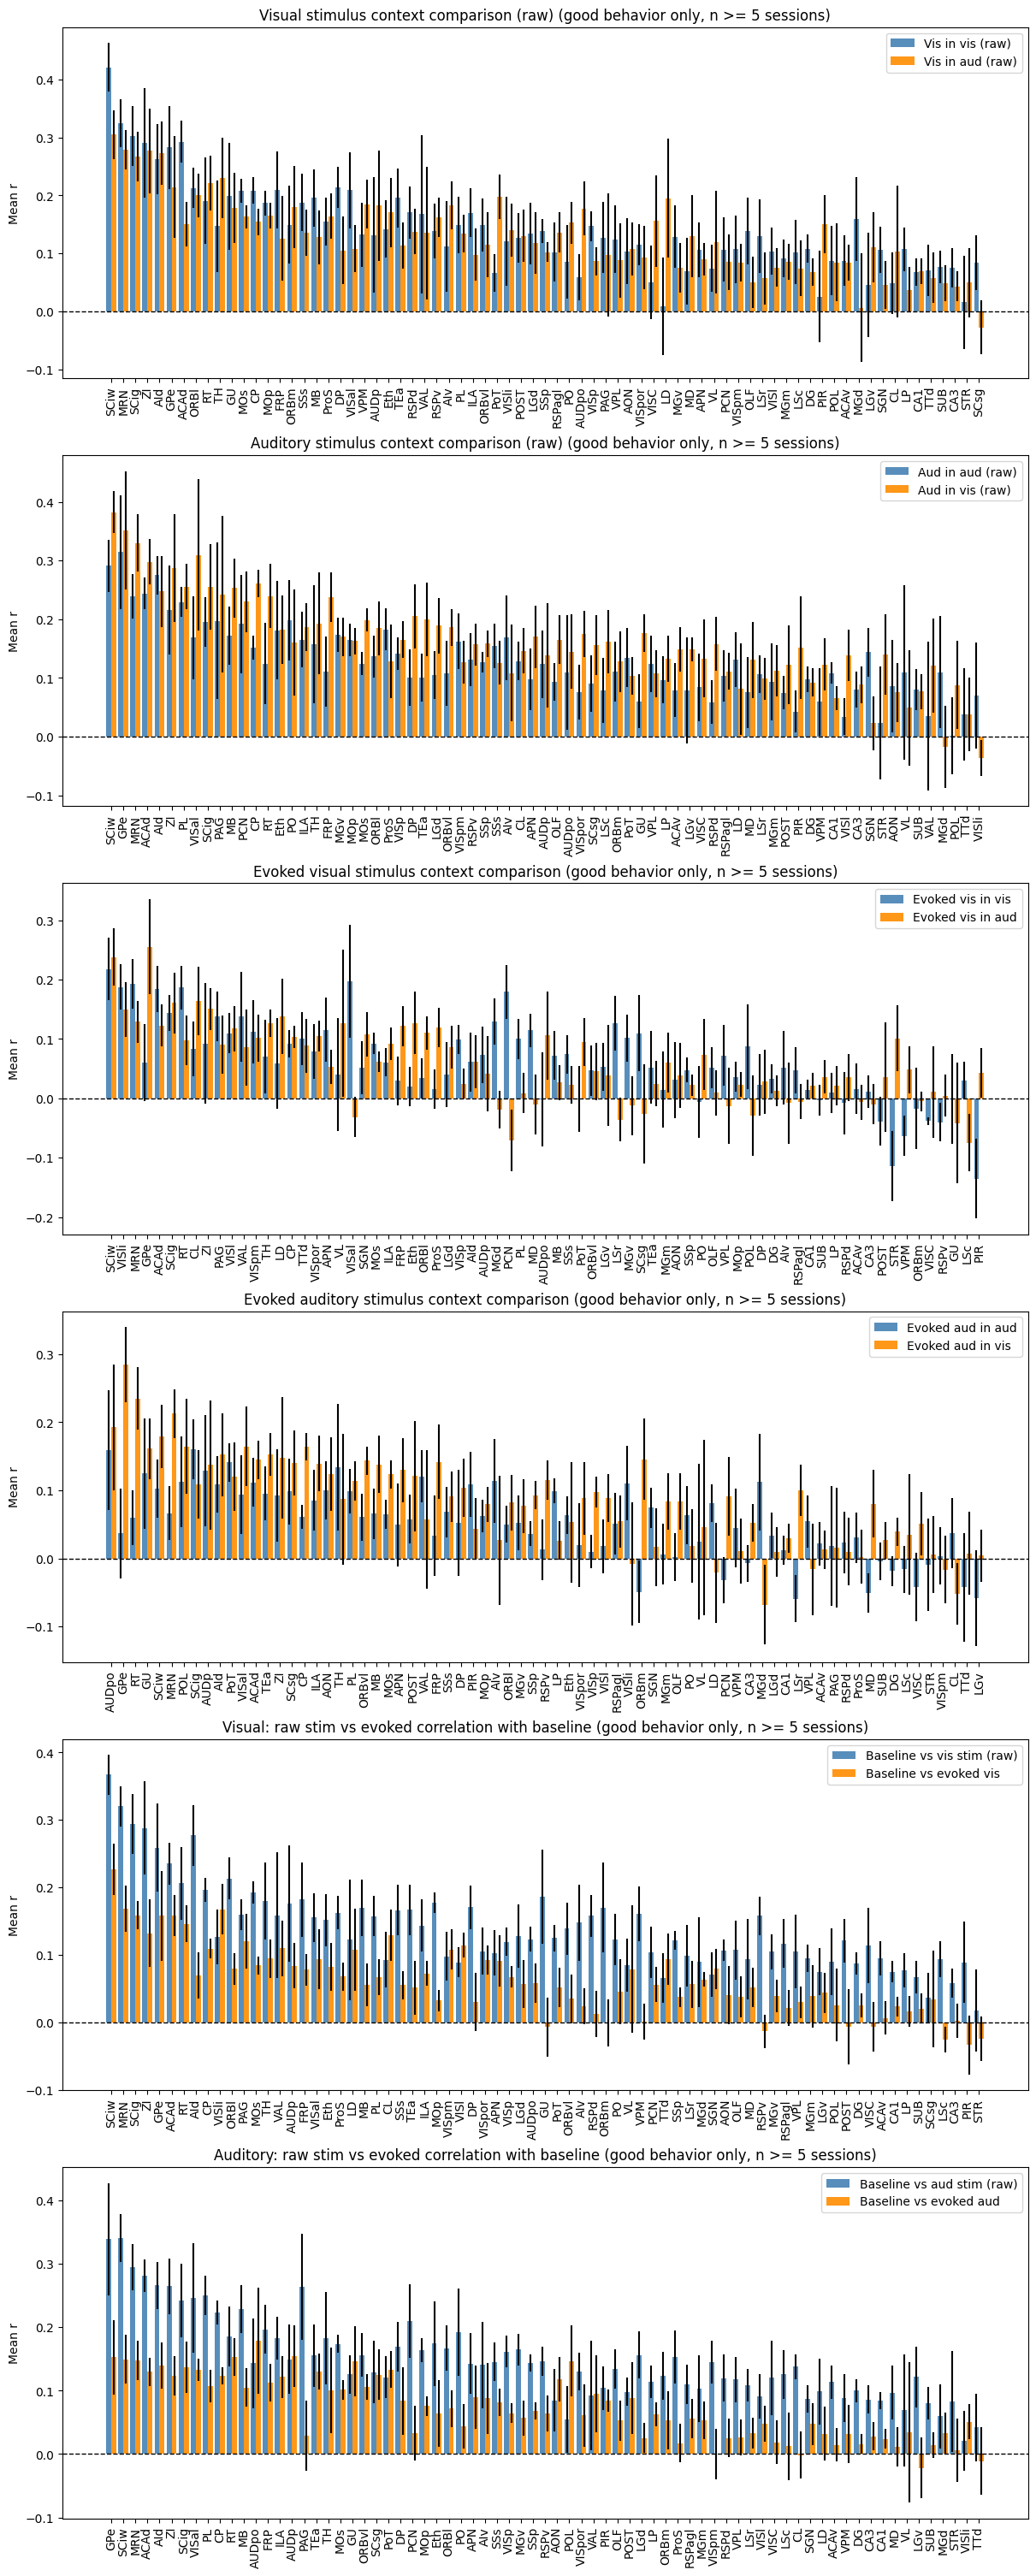

In [72]:
paired_plot_specs = [
    {
        'left_column': 'vis_stim_in_vis_context_r',
        'right_column': 'vis_stim_in_aud_context_r',
        'left_label': 'Vis in vis (raw)',
        'right_label': 'Vis in aud (raw)',
        'title': 'Visual stimulus context comparison (raw)',
    },
    {
        'left_column': 'aud_stim_in_aud_context_r',
        'right_column': 'aud_stim_in_vis_context_r',
        'left_label': 'Aud in aud (raw)',
        'right_label': 'Aud in vis (raw)',
        'title': 'Auditory stimulus context comparison (raw)',
    },
    {
        'left_column': 'evoked_vis_in_vis_context_r',
        'right_column': 'evoked_vis_in_aud_context_r',
        'left_label': 'Evoked vis in vis',
        'right_label': 'Evoked vis in aud',
        'title': 'Evoked visual stimulus context comparison',
    },
    {
        'left_column': 'evoked_aud_in_aud_context_r',
        'right_column': 'evoked_aud_in_vis_context_r',
        'left_label': 'Evoked aud in aud',
        'right_label': 'Evoked aud in vis',
        'title': 'Evoked auditory stimulus context comparison',
    },
    # Raw vs evoked direct comparisons
    {
        'left_column': 'baseline_vis_r',
        'right_column': 'baseline_evoked_vis_r',
        'left_label': 'Baseline vs vis stim (raw)',
        'right_label': 'Baseline vs evoked vis',
        'title': 'Visual: raw stim vs evoked correlation with baseline',
    },
    {
        'left_column': 'baseline_aud_r',
        'right_column': 'baseline_evoked_aud_r',
        'left_label': 'Baseline vs aud stim (raw)',
        'right_label': 'Baseline vs evoked aud',
        'title': 'Auditory: raw stim vs evoked correlation with baseline',
    },
]

fig, axes = plt.subplots(len(paired_plot_specs), 1, figsize=(12, 5 * len(paired_plot_specs)), constrained_layout=True)
bar_width = 0.42

for ax, spec in zip(np.atleast_1d(axes), paired_plot_specs):
    left_column = spec['left_column']
    right_column = spec['right_column']

    summary_subset = structure_corr_summary_df[
        [
            'structure',
            f'{left_column}_mean',
            f'{left_column}_sem',
            f'{left_column}_count',
            f'{right_column}_mean',
            f'{right_column}_sem',
            f'{right_column}_count',
        ]
    ].dropna(subset=[f'{left_column}_mean', f'{right_column}_mean'])

    summary_subset = summary_subset.loc[
        (summary_subset[f'{left_column}_count'] >= min_sessions_for_plot)
        & (summary_subset[f'{right_column}_count'] >= min_sessions_for_plot)
    ].copy()

    summary_subset['sort_key'] = summary_subset[
        [f'{left_column}_mean', f'{right_column}_mean']
    ].mean(axis=1)
    summary_subset = summary_subset.sort_values('sort_key', ascending=False)

    x = np.arange(len(summary_subset))

    ax.bar(
        x - bar_width / 2,
        summary_subset[f'{left_column}_mean'],
        width=bar_width,
        yerr=summary_subset[f'{left_column}_sem'],
        label=spec['left_label'],
        color='steelblue',
        alpha=0.9,
        capsize=0,
    )
    ax.bar(
        x + bar_width / 2,
        summary_subset[f'{right_column}_mean'],
        width=bar_width,
        yerr=summary_subset[f'{right_column}_sem'],
        label=spec['right_label'],
        color='darkorange',
        alpha=0.9,
        capsize=0,
    )

    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f"{spec['title']} (good behavior only, n >= {min_sessions_for_plot} sessions)")
    ax.set_ylabel('Mean r')
    ax.set_xticks(x)
    ax.set_xticklabels(summary_subset['structure'], rotation=90)
    ax.legend()

plt.show()

In [73]:
diagnostic_records = []

for session_id in dr_good_behavior_list:
    session_info = npc_lims.get_session_info(session_id)
    trials_check = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')

    trial_index_matches_index = np.array_equal(
        trials_check.index.to_numpy(),
        trials_check['trial_index'].to_numpy(),
    )
    vis_subset_index_matches = np.array_equal(
        trials_check.query('is_vis_target').index.to_numpy(),
        trials_check.query('is_vis_target')['trial_index'].to_numpy(),
    )
    aud_subset_index_matches = np.array_equal(
        trials_check.query('is_aud_target').index.to_numpy(),
        trials_check.query('is_aud_target')['trial_index'].to_numpy(),
    )

    diagnostic_records.append({
        'session_id': session_id,
        'trial_index_matches_index': trial_index_matches_index,
        'vis_subset_index_matches': vis_subset_index_matches,
        'aud_subset_index_matches': aud_subset_index_matches,
        'n_trials': len(trials_check),
        'n_instruction_trials': int(trials_check['is_instruction'].sum()),
    })

diagnostic_df = pd.DataFrame(diagnostic_records)
diagnostic_df

print('Sessions with full trial_index/index match:', diagnostic_df['trial_index_matches_index'].sum(), '/', len(diagnostic_df))
print('Sessions with vis subset match:', diagnostic_df['vis_subset_index_matches'].sum(), '/', len(diagnostic_df))
print('Sessions with aud subset match:', diagnostic_df['aud_subset_index_matches'].sum(), '/', len(diagnostic_df))

mismatch_sessions = diagnostic_df.loc[
    ~(
        diagnostic_df['trial_index_matches_index']
        & diagnostic_df['vis_subset_index_matches']
        & diagnostic_df['aud_subset_index_matches']
    )
]
mismatch_sessions

759434_2025-02-06 cached trials loaded
686740_2023-10-25 cached trials loaded
759434_2025-02-07 cached trials loaded
713655_2024-08-08 cached trials loaded
714753_2024-07-01 cached trials loaded
636766_2023-01-25 cached trials loaded
644866_2023-02-09 cached trials loaded
743199_2024-12-05 cached trials loaded
708016_2024-05-01 cached trials loaded
674562_2023-10-03 cached trials loaded
706401_2024-04-23 cached trials loaded
715710_2024-07-16 cached trials loaded
744740_2024-11-11 cached trials loaded
662892_2023-08-23 cached trials loaded
746439_2025-01-31 cached trials loaded
712815_2024-05-23 cached trials loaded
744740_2024-11-14 cached trials loaded
674562_2023-10-04 cached trials loaded
666986_2023-08-17 cached trials loaded
636766_2023-01-26 cached trials loaded
667252_2023-09-25 cached trials loaded
761583_2024-12-17 cached trials loaded
649943_2023-02-15 cached trials loaded
649943_2023-02-14 cached trials loaded
649943_2023-02-16 cached trials loaded
713655_2024-08-06 cached 

,session_id,trial_index_matches_index,vis_subset_index_matches,aud_subset_index_matches,n_trials,n_instruction_trials


In [74]:
selection_check_records = []

for row in results_df.itertuples(index=False):
    trial_metadata = get_session_trial_metadata(row.session_id)
    valid_trials = trial_metadata.loc[~trial_metadata['is_instruction'].fillna(False)].index

    baseline_vis_trials = pd.Index(row.baseline_trial_indices[np.asarray(row.baseline_labels).astype(bool)]).intersection(valid_trials)
    baseline_aud_trials = pd.Index(row.baseline_trial_indices[~np.asarray(row.baseline_labels).astype(bool)]).intersection(valid_trials)
    vis_vis_trials = pd.Index(row.vis_stim_trial_indices[np.asarray(row.vis_stim_labels).astype(bool)]).intersection(valid_trials)
    vis_aud_trials = pd.Index(row.vis_stim_trial_indices[~np.asarray(row.vis_stim_labels).astype(bool)]).intersection(valid_trials)
    aud_vis_trials = pd.Index(row.aud_stim_trial_indices[np.asarray(row.aud_stim_labels).astype(bool)]).intersection(valid_trials)
    aud_aud_trials = pd.Index(row.aud_stim_trial_indices[~np.asarray(row.aud_stim_labels).astype(bool)]).intersection(valid_trials)

    current_vis_in_vis = baseline_vis_trials.intersection(pd.Index(row.vis_stim_trial_indices).intersection(valid_trials))
    explicit_vis_in_vis = pd.Index(row.baseline_trial_indices).intersection(vis_vis_trials)

    current_vis_in_aud = baseline_aud_trials.intersection(pd.Index(row.vis_stim_trial_indices).intersection(valid_trials))
    explicit_vis_in_aud = pd.Index(row.baseline_trial_indices).intersection(vis_aud_trials)

    current_aud_in_vis = baseline_vis_trials.intersection(pd.Index(row.aud_stim_trial_indices).intersection(valid_trials))
    explicit_aud_in_vis = pd.Index(row.baseline_trial_indices).intersection(aud_vis_trials)

    current_aud_in_aud = baseline_aud_trials.intersection(pd.Index(row.aud_stim_trial_indices).intersection(valid_trials))
    explicit_aud_in_aud = pd.Index(row.baseline_trial_indices).intersection(aud_aud_trials)

    selection_check_records.append({
        'session_id': row.session_id,
        'structure': row.structure,
        'vis_in_vis_same_trials': current_vis_in_vis.equals(explicit_vis_in_vis),
        'vis_in_aud_same_trials': current_vis_in_aud.equals(explicit_vis_in_aud),
        'aud_in_vis_same_trials': current_aud_in_vis.equals(explicit_aud_in_vis),
        'aud_in_aud_same_trials': current_aud_in_aud.equals(explicit_aud_in_aud),
    })

selection_check_df = pd.DataFrame(selection_check_records)
selection_check_df

print('vis_in_vis identical:', selection_check_df['vis_in_vis_same_trials'].sum(), '/', len(selection_check_df))
print('vis_in_aud identical:', selection_check_df['vis_in_aud_same_trials'].sum(), '/', len(selection_check_df))
print('aud_in_vis identical:', selection_check_df['aud_in_vis_same_trials'].sum(), '/', len(selection_check_df))
print('aud_in_aud identical:', selection_check_df['aud_in_aud_same_trials'].sum(), '/', len(selection_check_df))

selection_check_df.loc[
    ~(
        selection_check_df['vis_in_vis_same_trials']
        & selection_check_df['vis_in_aud_same_trials']
        & selection_check_df['aud_in_vis_same_trials']
        & selection_check_df['aud_in_aud_same_trials']
    )
]

vis_in_vis identical: 1876 / 1876
vis_in_aud identical: 1876 / 1876
aud_in_vis identical: 1876 / 1876
aud_in_aud identical: 1876 / 1876


,session_id,structure,vis_in_vis_same_trials,vis_in_aud_same_trials,aud_in_vis_same_trials,aud_in_aud_same_trials


In [75]:
from itertools import combinations


def compute_cross_area_same_projection_correlation(
    values_a,
    trial_indices_a,
    values_b,
    trial_indices_b,
    trial_metadata,
    labels_a=None,
    labels_b=None,
    label_filter=None,
):
    projection_a = make_projection_df(values_a, trial_indices_a, trial_metadata, labels=labels_a)
    projection_b = make_projection_df(values_b, trial_indices_b, trial_metadata, labels=labels_b)

    if label_filter is not None:
        projection_a = projection_a.loc[projection_a['label'] == label_filter]
        projection_b = projection_b.loc[projection_b['label'] == label_filter]

    common_trial_indices = projection_a.index.intersection(projection_b.index)
    aligned_a = projection_a.loc[common_trial_indices, 'value'].to_numpy()
    aligned_b = projection_b.loc[common_trial_indices, 'value'].to_numpy()

    if len(common_trial_indices) < 2:
        return np.nan, np.nan, len(common_trial_indices)

    if np.unique(aligned_a).size < 2 or np.unique(aligned_b).size < 2:
        return np.nan, np.nan, len(common_trial_indices)

    r_value, p_value = stats.pearsonr(aligned_a, aligned_b)
    return r_value, p_value, len(common_trial_indices)


good_behavior_session_set = set(np.asarray(dr_good_behavior_list).tolist())
cross_area_records = []

for session_id, session_results_df in results_df.groupby('session_id'):
    trial_metadata = get_session_trial_metadata(session_id)
    session_rows = session_results_df.sort_values('structure').to_dict('records')

    for row_a, row_b in combinations(session_rows, 2):
        # --- Raw stimulus cross-area correlations ---
        baseline_r, baseline_p, baseline_n = compute_cross_area_same_projection_correlation(
            row_a['baseline_projection'], row_a['baseline_trial_indices'],
            row_b['baseline_projection'], row_b['baseline_trial_indices'],
            trial_metadata, labels_a=row_a['baseline_labels'], labels_b=row_b['baseline_labels'],
        )
        vis_stim_r, vis_stim_p, vis_stim_n = compute_cross_area_same_projection_correlation(
            row_a['vis_stim_projection'], row_a['vis_stim_trial_indices'],
            row_b['vis_stim_projection'], row_b['vis_stim_trial_indices'],
            trial_metadata, labels_a=row_a['vis_stim_labels'], labels_b=row_b['vis_stim_labels'],
        )
        aud_stim_r, aud_stim_p, aud_stim_n = compute_cross_area_same_projection_correlation(
            row_a['aud_stim_projection'], row_a['aud_stim_trial_indices'],
            row_b['aud_stim_projection'], row_b['aud_stim_trial_indices'],
            trial_metadata, labels_a=row_a['aud_stim_labels'], labels_b=row_b['aud_stim_labels'],
        )

        vis_in_vis_r, vis_in_vis_p, vis_in_vis_n = compute_cross_area_same_projection_correlation(
            row_a['vis_stim_projection'], row_a['vis_stim_trial_indices'],
            row_b['vis_stim_projection'], row_b['vis_stim_trial_indices'],
            trial_metadata, labels_a=row_a['vis_stim_labels'], labels_b=row_b['vis_stim_labels'],
            label_filter=True,
        )
        vis_in_aud_r, vis_in_aud_p, vis_in_aud_n = compute_cross_area_same_projection_correlation(
            row_a['vis_stim_projection'], row_a['vis_stim_trial_indices'],
            row_b['vis_stim_projection'], row_b['vis_stim_trial_indices'],
            trial_metadata, labels_a=row_a['vis_stim_labels'], labels_b=row_b['vis_stim_labels'],
            label_filter=False,
        )
        aud_in_vis_r, aud_in_vis_p, aud_in_vis_n = compute_cross_area_same_projection_correlation(
            row_a['aud_stim_projection'], row_a['aud_stim_trial_indices'],
            row_b['aud_stim_projection'], row_b['aud_stim_trial_indices'],
            trial_metadata, labels_a=row_a['aud_stim_labels'], labels_b=row_b['aud_stim_labels'],
            label_filter=True,
        )
        aud_in_aud_r, aud_in_aud_p, aud_in_aud_n = compute_cross_area_same_projection_correlation(
            row_a['aud_stim_projection'], row_a['aud_stim_trial_indices'],
            row_b['aud_stim_projection'], row_b['aud_stim_trial_indices'],
            trial_metadata, labels_a=row_a['aud_stim_labels'], labels_b=row_b['aud_stim_labels'],
            label_filter=False,
        )

        # --- Evoked cross-area correlations ---
        has_evoked = row_a['evoked_vis_projection'] is not None and row_b['evoked_vis_projection'] is not None
        if has_evoked:
            evoked_vis_r, evoked_vis_p, evoked_vis_n = compute_cross_area_same_projection_correlation(
                row_a['evoked_vis_projection'], row_a['evoked_vis_trial_indices'],
                row_b['evoked_vis_projection'], row_b['evoked_vis_trial_indices'],
                trial_metadata, labels_a=row_a['evoked_vis_labels'], labels_b=row_b['evoked_vis_labels'],
            )
            evoked_aud_r, evoked_aud_p, evoked_aud_n = compute_cross_area_same_projection_correlation(
                row_a['evoked_aud_projection'], row_a['evoked_aud_trial_indices'],
                row_b['evoked_aud_projection'], row_b['evoked_aud_trial_indices'],
                trial_metadata, labels_a=row_a['evoked_aud_labels'], labels_b=row_b['evoked_aud_labels'],
            )
            evoked_vis_in_vis_r, evoked_vis_in_vis_p, evoked_vis_in_vis_n = compute_cross_area_same_projection_correlation(
                row_a['evoked_vis_projection'], row_a['evoked_vis_trial_indices'],
                row_b['evoked_vis_projection'], row_b['evoked_vis_trial_indices'],
                trial_metadata, labels_a=row_a['evoked_vis_labels'], labels_b=row_b['evoked_vis_labels'],
                label_filter=True,
            )
            evoked_vis_in_aud_r, evoked_vis_in_aud_p, evoked_vis_in_aud_n = compute_cross_area_same_projection_correlation(
                row_a['evoked_vis_projection'], row_a['evoked_vis_trial_indices'],
                row_b['evoked_vis_projection'], row_b['evoked_vis_trial_indices'],
                trial_metadata, labels_a=row_a['evoked_vis_labels'], labels_b=row_b['evoked_vis_labels'],
                label_filter=False,
            )
            evoked_aud_in_vis_r, evoked_aud_in_vis_p, evoked_aud_in_vis_n = compute_cross_area_same_projection_correlation(
                row_a['evoked_aud_projection'], row_a['evoked_aud_trial_indices'],
                row_b['evoked_aud_projection'], row_b['evoked_aud_trial_indices'],
                trial_metadata, labels_a=row_a['evoked_aud_labels'], labels_b=row_b['evoked_aud_labels'],
                label_filter=True,
            )
            evoked_aud_in_aud_r, evoked_aud_in_aud_p, evoked_aud_in_aud_n = compute_cross_area_same_projection_correlation(
                row_a['evoked_aud_projection'], row_a['evoked_aud_trial_indices'],
                row_b['evoked_aud_projection'], row_b['evoked_aud_trial_indices'],
                trial_metadata, labels_a=row_a['evoked_aud_labels'], labels_b=row_b['evoked_aud_labels'],
                label_filter=False,
            )
        else:
            evoked_vis_r = evoked_vis_p = evoked_vis_n = np.nan
            evoked_aud_r = evoked_aud_p = evoked_aud_n = np.nan
            evoked_vis_in_vis_r = evoked_vis_in_vis_p = evoked_vis_in_vis_n = np.nan
            evoked_vis_in_aud_r = evoked_vis_in_aud_p = evoked_vis_in_aud_n = np.nan
            evoked_aud_in_vis_r = evoked_aud_in_vis_p = evoked_aud_in_vis_n = np.nan
            evoked_aud_in_aud_r = evoked_aud_in_aud_p = evoked_aud_in_aud_n = np.nan

        cross_area_records.append({
            'session_id': session_id,
            'is_good_behavior_session': session_id in good_behavior_session_set,
            'structure_1': row_a['structure'],
            'structure_2': row_b['structure'],
            'structure_pair': f"{row_a['structure']}__{row_b['structure']}",
            'n_units_1': row_a['n_units'],
            'n_units_2': row_b['n_units'],
            # Raw
            'baseline_cross_area_r': baseline_r,
            'baseline_cross_area_p': baseline_p,
            'baseline_cross_area_n_trials': baseline_n,
            'vis_stim_cross_area_r': vis_stim_r,
            'vis_stim_cross_area_p': vis_stim_p,
            'vis_stim_cross_area_n_trials': vis_stim_n,
            'aud_stim_cross_area_r': aud_stim_r,
            'aud_stim_cross_area_p': aud_stim_p,
            'aud_stim_cross_area_n_trials': aud_stim_n,
            'vis_stim_in_vis_context_cross_area_r': vis_in_vis_r,
            'vis_stim_in_vis_context_cross_area_p': vis_in_vis_p,
            'vis_stim_in_vis_context_cross_area_n_trials': vis_in_vis_n,
            'vis_stim_in_aud_context_cross_area_r': vis_in_aud_r,
            'vis_stim_in_aud_context_cross_area_p': vis_in_aud_p,
            'vis_stim_in_aud_context_cross_area_n_trials': vis_in_aud_n,
            'aud_stim_in_vis_context_cross_area_r': aud_in_vis_r,
            'aud_stim_in_vis_context_cross_area_p': aud_in_vis_p,
            'aud_stim_in_vis_context_cross_area_n_trials': aud_in_vis_n,
            'aud_stim_in_aud_context_cross_area_r': aud_in_aud_r,
            'aud_stim_in_aud_context_cross_area_p': aud_in_aud_p,
            'aud_stim_in_aud_context_cross_area_n_trials': aud_in_aud_n,
            # Evoked
            'evoked_vis_cross_area_r': evoked_vis_r,
            'evoked_vis_cross_area_p': evoked_vis_p,
            'evoked_vis_cross_area_n_trials': evoked_vis_n,
            'evoked_aud_cross_area_r': evoked_aud_r,
            'evoked_aud_cross_area_p': evoked_aud_p,
            'evoked_aud_cross_area_n_trials': evoked_aud_n,
            'evoked_vis_in_vis_context_cross_area_r': evoked_vis_in_vis_r,
            'evoked_vis_in_vis_context_cross_area_p': evoked_vis_in_vis_p,
            'evoked_vis_in_vis_context_cross_area_n_trials': evoked_vis_in_vis_n,
            'evoked_vis_in_aud_context_cross_area_r': evoked_vis_in_aud_r,
            'evoked_vis_in_aud_context_cross_area_p': evoked_vis_in_aud_p,
            'evoked_vis_in_aud_context_cross_area_n_trials': evoked_vis_in_aud_n,
            'evoked_aud_in_vis_context_cross_area_r': evoked_aud_in_vis_r,
            'evoked_aud_in_vis_context_cross_area_p': evoked_aud_in_vis_p,
            'evoked_aud_in_vis_context_cross_area_n_trials': evoked_aud_in_vis_n,
            'evoked_aud_in_aud_context_cross_area_r': evoked_aud_in_aud_r,
            'evoked_aud_in_aud_context_cross_area_p': evoked_aud_in_aud_p,
            'evoked_aud_in_aud_context_cross_area_n_trials': evoked_aud_in_aud_n,
        })

cross_area_projection_corr_df = pd.DataFrame.from_records(cross_area_records)
cross_area_projection_corr_df = cross_area_projection_corr_df.sort_values(
    ['session_id', 'structure_1', 'structure_2']
).reset_index(drop=True)

cross_area_projection_corr_good_behavior_df = cross_area_projection_corr_df.query(
    'is_good_behavior_session'
).reset_index(drop=True)

cross_area_projection_corr_df

,session_id,is_good_behavior_session,structure_1,structure_2,structure_pair,n_units_1,n_units_2,baseline_cross_area_r,baseline_cross_area_p,baseline_cross_area_n_trials,...,evoked_vis_in_vis_context_cross_area_n_trials,evoked_vis_in_aud_context_cross_area_r,evoked_vis_in_aud_context_cross_area_p,evoked_vis_in_aud_context_cross_area_n_trials,evoked_aud_in_vis_context_cross_area_r,evoked_aud_in_vis_context_cross_area_p,evoked_aud_in_vis_context_cross_area_n_trials,evoked_aud_in_aud_context_cross_area_r,evoked_aud_in_aud_context_cross_area_p,evoked_aud_in_aud_context_cross_area_n_trials
0,626791_2022-08-15,True,AUDp,AUDpo,AUDp__AUDpo,20,37,0.399412,1.261467e-18,449,...,53,-0.027733,0.851572,48,0.296375,0.029548,54,0.212013,0.152524,47
1,626791_2022-08-15,True,AUDp,CA1,AUDp__CA1,20,27,0.155645,9.360931e-04,449,...,53,-0.052527,0.722911,48,0.188879,0.171361,54,0.230789,0.118580,47
2,626791_2022-08-15,True,AUDp,CP,AUDp__CP,20,60,0.323256,2.219966e-12,449,...,53,0.006072,0.967328,48,-0.091285,0.511514,54,0.131792,0.377208,47
3,626791_2022-08-15,True,AUDp,DG,AUDp__DG,20,19,0.258236,2.838946e-08,449,...,53,-0.124263,0.400071,48,-0.001216,0.993039,54,-0.019687,0.895500,47
4,626791_2022-08-15,True,AUDp,LD,AUDp__LD,20,15,0.405525,3.346051e-19,449,...,53,0.033603,0.820627,48,-0.245343,0.073751,54,-0.100178,0.502870,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12041,761583_2024-12-17,True,LP,SSp,LP__SSp,10,43,0.213052,9.435816e-07,520,...,59,0.133899,0.320710,57,0.260689,0.048104,58,0.012445,0.924161,61
12042,761583_2024-12-17,True,LP,VPM,LP__VPM,10,25,0.130082,2.960265e-03,520,...,59,0.105710,0.433856,57,0.170344,0.201100,58,-0.119362,0.359539,61
12043,761583_2024-12-17,True,PO,SSp,PO__SSp,23,43,0.315036,1.913143e-13,520,...,59,0.100687,0.456134,57,0.172827,0.194513,58,0.204955,0.113080,61
12044,761583_2024-12-17,True,PO,VPM,PO__VPM,23,25,0.297206,4.581998e-12,520,...,59,0.104589,0.438774,57,0.088664,0.508065,58,-0.053371,0.682902,61


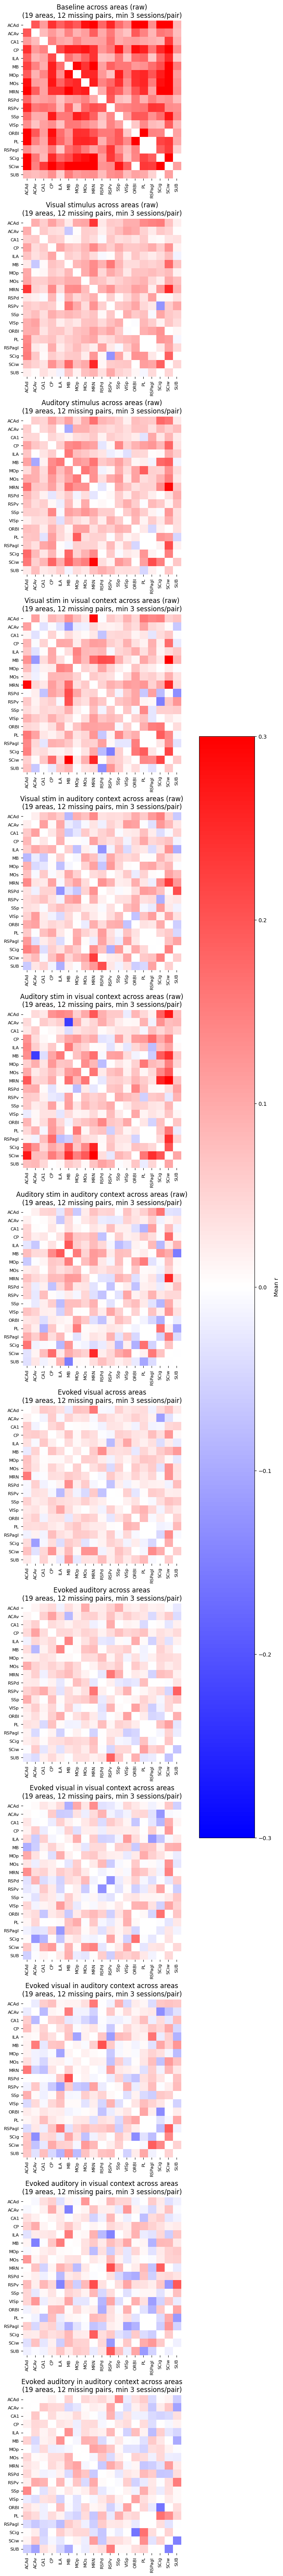

Thresholds: min_sessions_per_pair=3, max_missing_per_area=2


,structure_1,structure_2,baseline_cross_area_r_mean,baseline_cross_area_r_count,vis_stim_cross_area_r_mean,vis_stim_cross_area_r_count,aud_stim_cross_area_r_mean,aud_stim_cross_area_r_count,vis_stim_in_vis_context_cross_area_r_mean,vis_stim_in_vis_context_cross_area_r_count,...,evoked_aud_cross_area_r_mean,evoked_aud_cross_area_r_count,evoked_vis_in_vis_context_cross_area_r_mean,evoked_vis_in_vis_context_cross_area_r_count,evoked_vis_in_aud_context_cross_area_r_mean,evoked_vis_in_aud_context_cross_area_r_count,evoked_aud_in_vis_context_cross_area_r_mean,evoked_aud_in_vis_context_cross_area_r_count,evoked_aud_in_aud_context_cross_area_r_mean,evoked_aud_in_aud_context_cross_area_r_count
0,ACAd,ACAv,0.198271,16,0.095782,16,0.057459,16,0.110467,16,...,0.013059,16,0.006853,16,-0.022333,16,-0.007490,16,0.001196,16
1,ACAd,AId,0.411837,1,0.202148,1,0.320863,1,0.273677,1,...,-0.050560,1,-0.027798,1,0.048303,1,-0.078575,1,-0.037865,1
2,ACAd,AIp,0.168826,1,0.163199,1,0.004191,1,0.073370,1,...,0.111760,1,0.018198,1,-0.105828,1,0.211293,1,-0.000640,1
3,ACAd,AON,0.118657,3,-0.066862,3,0.045664,3,-0.082682,3,...,0.069325,3,-0.097252,3,-0.043461,3,0.062989,3,0.097125,3
4,ACAd,APN,0.115051,2,0.116511,2,0.096460,2,0.118118,2,...,0.194830,2,0.246771,2,0.033671,2,0.252711,2,0.054379,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,VPL,VPM,0.153955,5,0.012732,5,-0.011624,5,0.082031,5,...,0.098223,5,-0.090931,5,0.016550,5,0.112575,5,0.056803,5
2819,VPL,ZI,0.142892,1,0.084992,1,0.039504,1,0.196878,1,...,0.031555,1,0.291041,1,0.129370,1,0.035520,1,0.025234,1
2820,VPM,ZI,0.261850,1,-0.055978,1,-0.108220,1,-0.156539,1,...,0.040844,1,-0.104934,1,-0.108413,1,0.103773,1,-0.044846,1
2821,VPMpc,ZI,0.046725,1,0.209483,1,-0.007840,1,0.146545,1,...,0.080709,1,-0.248324,1,0.102439,1,0.200009,1,-0.072938,1


In [77]:
cross_area_heatmap_source_df = cross_area_projection_corr_good_behavior_df.copy()

# --- configurable thresholds ---
min_sessions_per_pair = 3       # require at least this many sessions for a pair to count
max_missing_per_area = 2        # each area in the final heatmap can have at most this many missing pairs

cross_area_metrics = [
    'baseline_cross_area_r',
    'vis_stim_cross_area_r',
    'aud_stim_cross_area_r',
    'vis_stim_in_vis_context_cross_area_r',
    'vis_stim_in_aud_context_cross_area_r',
    'aud_stim_in_vis_context_cross_area_r',
    'aud_stim_in_aud_context_cross_area_r',
    # Evoked
    'evoked_vis_cross_area_r',
    'evoked_aud_cross_area_r',
    'evoked_vis_in_vis_context_cross_area_r',
    'evoked_vis_in_aud_context_cross_area_r',
    'evoked_aud_in_vis_context_cross_area_r',
    'evoked_aud_in_aud_context_cross_area_r',
]

cross_area_metric_labels = {
    'baseline_cross_area_r': 'Baseline across areas (raw)',
    'vis_stim_cross_area_r': 'Visual stimulus across areas (raw)',
    'aud_stim_cross_area_r': 'Auditory stimulus across areas (raw)',
    'vis_stim_in_vis_context_cross_area_r': 'Visual stim in visual context across areas (raw)',
    'vis_stim_in_aud_context_cross_area_r': 'Visual stim in auditory context across areas (raw)',
    'aud_stim_in_vis_context_cross_area_r': 'Auditory stim in visual context across areas (raw)',
    'aud_stim_in_aud_context_cross_area_r': 'Auditory stim in auditory context across areas (raw)',
    'evoked_vis_cross_area_r': 'Evoked visual across areas',
    'evoked_aud_cross_area_r': 'Evoked auditory across areas',
    'evoked_vis_in_vis_context_cross_area_r': 'Evoked visual in visual context across areas',
    'evoked_vis_in_aud_context_cross_area_r': 'Evoked visual in auditory context across areas',
    'evoked_aud_in_vis_context_cross_area_r': 'Evoked auditory in visual context across areas',
    'evoked_aud_in_aud_context_cross_area_r': 'Evoked auditory in auditory context across areas',
}


def build_symmetric_heatmap_matrix(summary_df, value_column, count_column, min_sessions=3, max_missing=2):
    """Build a dense symmetric heatmap matrix, pruning sparse areas iteratively."""
    # filter pairs below min session count
    valid = summary_df[summary_df[count_column] >= min_sessions].copy()
    
    pair_matrix = valid.pivot(index='structure_1', columns='structure_2', values=value_column)
    matrix = pair_matrix.combine_first(pair_matrix.T)

    all_areas = sorted(set(matrix.index).union(matrix.columns))
    matrix = matrix.reindex(index=all_areas, columns=all_areas).copy()
    matrix_values = matrix.to_numpy(copy=True)
    np.fill_diagonal(matrix_values, np.nan)
    matrix.iloc[:, :] = matrix_values

    # remove areas with no data at all
    valid_area_mask = matrix.notna().any(axis=1) | matrix.notna().any(axis=0)
    matrix = matrix.loc[valid_area_mask, valid_area_mask]

    if matrix.empty:
        return matrix

    # iteratively remove the area with the most missing pairs 
    # until all remaining areas have <= max_missing NaN entries
    while len(matrix) > 0:
        n_missing = matrix.isna().sum(axis=1)
        worst_missing = n_missing.max()
        if worst_missing <= max_missing:
            break
        # remove the area with the most missing partners (ties: remove alphabetically last)
        worst_areas = n_missing[n_missing == worst_missing].index
        drop_area = sorted(worst_areas)[-1]
        matrix = matrix.drop(index=drop_area, columns=drop_area)

    if matrix.empty:
        return matrix

    # order by number of valid entries (descending), then alphabetically
    area_counts = matrix.notna().sum(axis=1)
    ordered_areas = (
        pd.DataFrame({
            'area': matrix.index,
            'count': area_counts.reindex(matrix.index).to_numpy(),
        })
        .sort_values(['count', 'area'], ascending=[False, True])['area']
        .tolist()
    )

    return matrix.loc[ordered_areas, ordered_areas]


# compute summary stats
cross_area_heatmap_summary_df = (
    cross_area_heatmap_source_df
    .groupby(['structure_1', 'structure_2'])[cross_area_metrics]
    .agg(['mean', 'count'])
)
cross_area_heatmap_summary_df.columns = [f'{metric}_{stat}' for metric, stat in cross_area_heatmap_summary_df.columns]
cross_area_heatmap_summary_df = cross_area_heatmap_summary_df.reset_index()

fig, axes = plt.subplots(len(cross_area_metrics), 1, figsize=(12, 5 * len(cross_area_metrics)), constrained_layout=True)

for ax, metric in zip(np.atleast_1d(axes), cross_area_metrics):
    metric_matrix = build_symmetric_heatmap_matrix(
        cross_area_heatmap_summary_df,
        f'{metric}_mean',
        f'{metric}_count',
        min_sessions=min_sessions_per_pair,
        max_missing=max_missing_per_area,
    )

    if metric_matrix.empty:
        ax.axis('off')
        ax.set_title(f"{cross_area_metric_labels[metric]} (no data after filtering)")
        continue

    masked_matrix = np.ma.masked_invalid(metric_matrix.to_numpy(dtype=float))
    image = ax.imshow(masked_matrix, cmap='bwr', vmin=-0.3, vmax=0.3, aspect='equal')

    ax.set_xticks(np.arange(len(metric_matrix.columns)))
    ax.set_xticklabels(metric_matrix.columns, rotation=90, fontsize=8)
    ax.set_yticks(np.arange(len(metric_matrix.index)))
    ax.set_yticklabels(metric_matrix.index, fontsize=8)
    n_areas = len(metric_matrix)
    n_missing = int(masked_matrix.mask.sum()) // 2 if hasattr(masked_matrix.mask, 'sum') else 0
    ax.set_title(f"{cross_area_metric_labels[metric]}\n({n_areas} areas, {n_missing} missing pairs, min {min_sessions_per_pair} sessions/pair)")

    for spine in ax.spines.values():
        spine.set_visible(False)

colorbar = fig.colorbar(image, ax=np.atleast_1d(axes), shrink=0.5)
colorbar.set_label('Mean r')

plt.show()

print(f"Thresholds: min_sessions_per_pair={min_sessions_per_pair}, max_missing_per_area={max_missing_per_area}")
cross_area_heatmap_summary_df